# Representation Stabilization — Results Inspection

Loads and visualizes all experimental results across three LR schedule conditions:
- **Cosine annealing** (`results/seed_*/`) — 5 seeds, surrogates at epoch 285
- **Step LR** (`results_steplr/seed_*/`) — 5 seeds, surrogates at epoch 230
- **Constant LR** (`results_constantlr/seed_*/`) — seed 42 only, surrogates at epochs 200 and 285

Run all cells top-to-bottom. The notebook exports to `results/results_inspection.html`.

## 0 · Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Locate repo root ──────────────────────────────────────────────────────────
_cwd = os.getcwd()
if os.path.exists(os.path.join(_cwd, 'results')):
    REPO_ROOT = _cwd
elif os.path.exists(os.path.join(_cwd, '..', 'results')):
    REPO_ROOT = os.path.abspath(os.path.join(_cwd, '..'))
else:
    raise RuntimeError(f'Cannot locate repo root from {_cwd}')

COSINE_ROOT   = os.path.join(REPO_ROOT, 'results')
STEPLR_ROOT   = os.path.join(REPO_ROOT, 'results_steplr')
CONSTLR_ROOT  = os.path.join(REPO_ROOT, 'results_constantlr')

SEEDS         = ['seed_0', 'seed_1', 'seed_2', 'seed_3', 'seed_42']
SEED_LABELS   = ['seed 0', 'seed 1', 'seed 2', 'seed 3', 'seed 42']

# Stabilization parameters (from config)
TAU = 0.02
K   = 5

# ── Publication style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'     : 'sans-serif',
    'font.size'       : 12,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 12,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'legend.fontsize' : 10,
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

# Condition colors used consistently throughout
COLOR_COSINE  = '#2166ac'   # blue
COLOR_STEPLR  = '#d6604d'   # red-orange
COLOR_CONSTLR = '#4dac26'   # green

SEED_PALETTE = sns.color_palette('Blues_d', 5)[::-1]

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'tau = {TAU},  K = {K}')

REPO_ROOT  : C:\Users\gabri\thesis
tau = 0.02,  K = 5


### Helper functions

In [2]:
def load_cka(results_dir, seed):
    """Load cka_results.csv for one seed directory."""
    path = os.path.join(results_dir, seed, 'cka_results.csv')
    df = pd.read_csv(path)
    df['seed'] = seed
    return df


def load_stabilization_summary(results_dir, seed):
    """Return dict {metric -> t_star_str} from stabilization_summary.csv."""
    path = os.path.join(results_dir, seed, 'stabilization_summary.csv')
    df = pd.read_csv(path)
    return dict(zip(df['metric'], df['t_star'].astype(str)))


def load_surrogates(results_dir, seed, epoch_tag):
    """Load all three surrogate CSVs for one seed at one epoch."""
    surrogate_types = ['linear', 'lightgbm', 'rf']
    rows = []
    for stype in surrogate_types:
        fname = f'surrogate_{stype}_epoch_{epoch_tag:04d}.csv'
        path  = os.path.join(results_dir, seed, fname)
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['seed'] = seed
            rows.append(df)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def surrogate_display_name(surrogate_type):
    mapping = {
        'logistic_regression' : 'Linear probe',
        'lightgbm'            : 'LightGBM',
        'random_forest'       : 'Random Forest',
    }
    return mapping.get(surrogate_type, surrogate_type)


def t_star_int_or_none(t_star_str):
    """Return int if t* was detected, else None."""
    try:
        return int(t_star_str)
    except (ValueError, TypeError):
        return None


print('Helper functions defined.')

Helper functions defined.


---
## 0.5 · Training Dynamics Overview

One 2×2 figure per LR condition (cosine annealing, step LR, constant LR), all for seed 42.  
Each figure shows four key training signals on a shared epoch x-axis:
- **Top left**: CKA change (1 − CKA) between consecutive checkpoints, with τ = 0.02 dashed baseline.
- **Top right**: Learning rate as recorded in `train.log` (log scale).
- **Bottom left**: Train and test accuracy over epochs.
- **Bottom right**: Train and test loss over epochs.

The dotted black vertical line marks t* across all four panels simultaneously.  
For constant LR no stabilisation is detected; panels are annotated 'NOT DETECTED' instead.

In [3]:
# ---- parse train.log for seed_42 across all three conditions ------------------
import re

def parse_train_log(log_path):
    """Return DataFrame with one row per epoch parsed from train.log."""
    pattern = re.compile(
        r'Epoch\s+(\d+)/\d+\s+'
        r'train_loss=([\d.]+)\s+'
        r'train_acc=([\d.]+)\s+'
        r'test_loss=([\d.]+)\s+'
        r'test_acc=([\d.]+)\s+'
        r'lr=([\d.]+)'
    )
    rows = []
    with open(log_path, 'r') as fh:
        for line in fh:
            m = pattern.search(line)
            if m:
                epoch_num, train_loss, train_acc, test_loss, test_acc, lr = m.groups()
                rows.append({
                    'epoch'      : int(epoch_num),
                    'train_loss' : float(train_loss),
                    'train_acc'  : float(train_acc),
                    'test_loss'  : float(test_loss),
                    'test_acc'   : float(test_acc),
                    'lr'         : float(lr),
                })
    return pd.DataFrame(rows)


cosine_log_s42  = parse_train_log(os.path.join(COSINE_ROOT,  'seed_42', 'train.log'))
steplr_log_s42  = parse_train_log(os.path.join(STEPLR_ROOT,  'seed_42', 'train.log'))
constlr_log_s42 = parse_train_log(os.path.join(CONSTLR_ROOT, 'seed_42', 'train.log'))

print(f'Cosine   log: {len(cosine_log_s42)} epochs '
      f'(epoch {cosine_log_s42.epoch.iloc[0]}..{cosine_log_s42.epoch.iloc[-1]})')
print(f'Step LR  log: {len(steplr_log_s42)} epochs '
      f'(epoch {steplr_log_s42.epoch.iloc[0]}..{steplr_log_s42.epoch.iloc[-1]})')
print(f'Const LR log: {len(constlr_log_s42)} epochs '
      f'(epoch {constlr_log_s42.epoch.iloc[0]}..{constlr_log_s42.epoch.iloc[-1]})')


Cosine   log: 300 epochs (epoch 1..300)
Step LR  log: 300 epochs (epoch 1..300)
Const LR log: 300 epochs (epoch 1..300)


Cosine  t* (seed 42) = 285
Step LR t* (seed 42) = 230
Const LR t* (seed 42) = None (not detected)


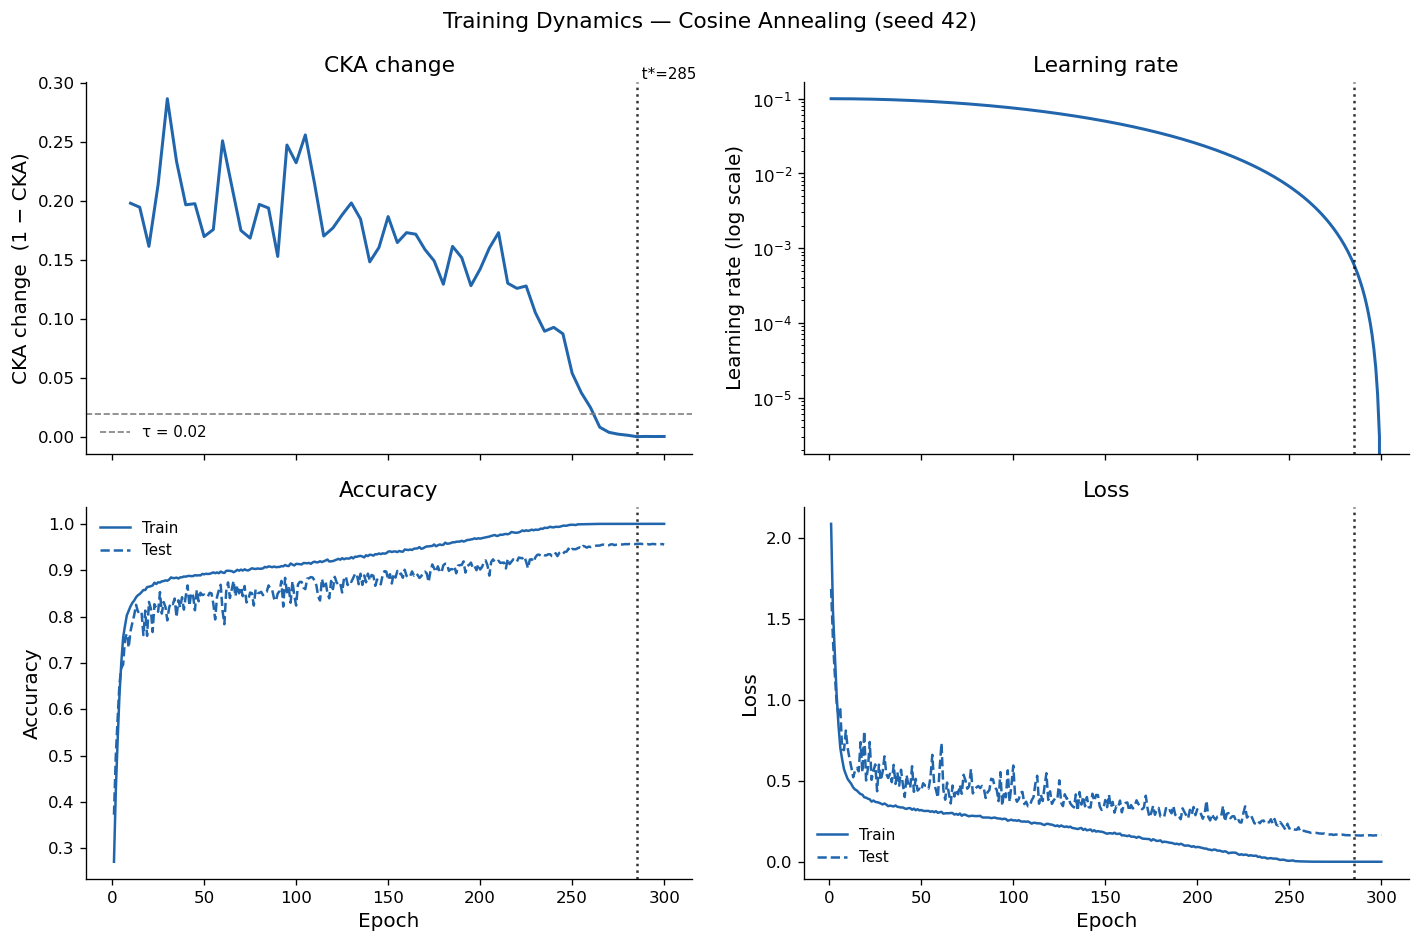

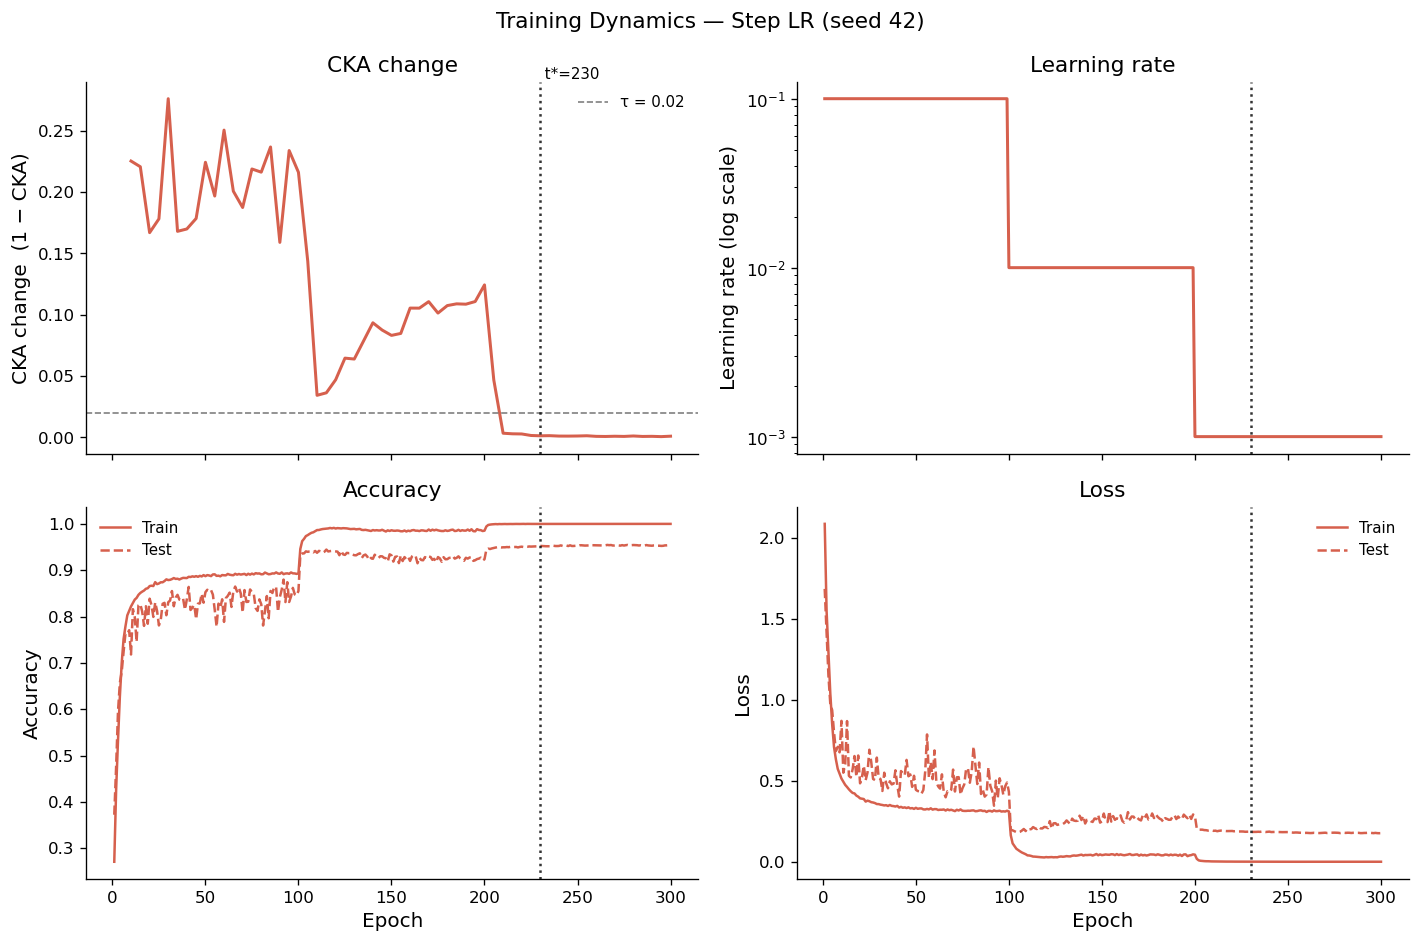

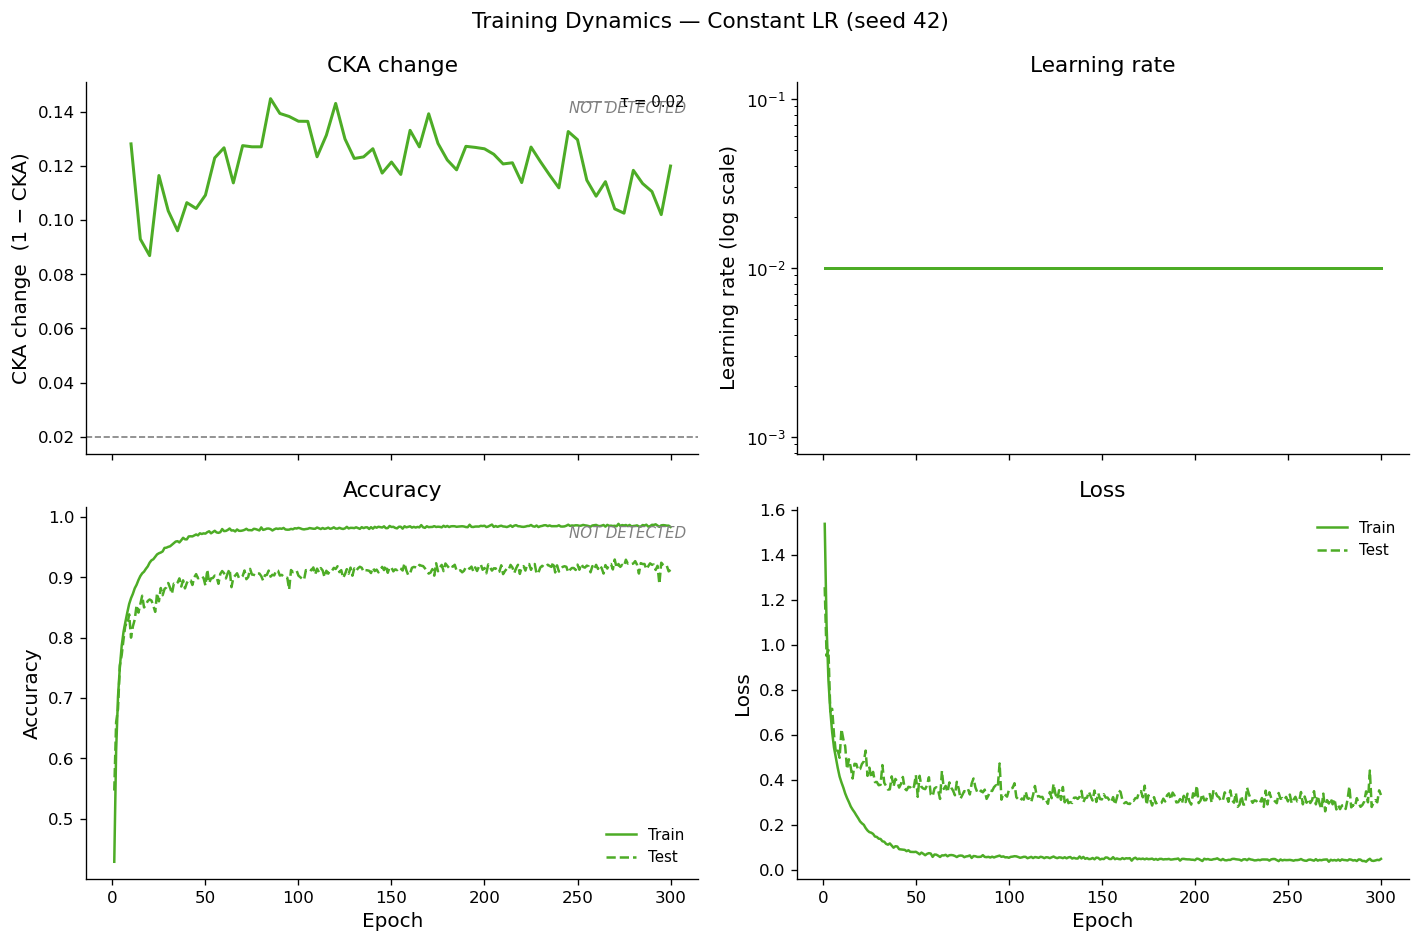

In [4]:
# ---- helper: 2x2 training dynamics figure ------------------------------------

def plot_dynamics_2x2(cka_df, log_df, t_star_epoch, condition_name,
                       condition_color, save_path):
    """2x2 figure: CKA change, LR, accuracy, loss -- shared x-axis, t* marked."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    ax_cka  = axes[0, 0]
    ax_lr   = axes[0, 1]
    ax_acc  = axes[1, 0]
    ax_loss = axes[1, 1]

    # Top left: CKA change (1 - CKA) from cka_results.csv
    ax_cka.plot(cka_df['epoch_curr'], cka_df['cka_change'],
                color=condition_color, linewidth=1.8)
    ax_cka.axhline(TAU, color='gray', linestyle='--', linewidth=1.0,
                   label=f'τ = {TAU}')
    ax_cka.set_ylabel('CKA change  (1 − CKA)')
    ax_cka.set_title('CKA change')
    ax_cka.legend(frameon=False, fontsize=9)

    # Top right: learning rate (log scale) from train.log
    ax_lr.plot(log_df['epoch'], log_df['lr'],
               color=condition_color, linewidth=1.8)
    ax_lr.set_yscale('log')
    ax_lr.set_ylabel('Learning rate (log scale)')
    ax_lr.set_title('Learning rate')

    # Bottom left: train and test accuracy
    ax_acc.plot(log_df['epoch'], log_df['train_acc'],
                color=condition_color, linewidth=1.5, label='Train')
    ax_acc.plot(log_df['epoch'], log_df['test_acc'],
                color=condition_color, linewidth=1.5, linestyle='--', label='Test')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_title('Accuracy')
    ax_acc.legend(frameon=False, fontsize=9)

    # Bottom right: train and test loss
    ax_loss.plot(log_df['epoch'], log_df['train_loss'],
                 color=condition_color, linewidth=1.5, label='Train')
    ax_loss.plot(log_df['epoch'], log_df['test_loss'],
                 color=condition_color, linewidth=1.5, linestyle='--', label='Test')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_title('Loss')
    ax_loss.legend(frameon=False, fontsize=9)

    # Draw t* vertical line simultaneously across all four panels
    if t_star_epoch is not None:
        for ax in axes.flat:
            ax.axvline(t_star_epoch, color='black', linestyle=':',
                       linewidth=1.5, alpha=0.8)
        # Label in top-left panel using xaxis transform (x=data, y=axes fraction)
        ax_cka.text(
            t_star_epoch, 1.0, f' t*={t_star_epoch}',
            transform=ax_cka.get_xaxis_transform(),
            fontsize=9, color='black', va='bottom',
        )
    else:
        # No t* detected -- annotate on the CKA and accuracy panels
        for ax in [ax_cka, ax_acc]:
            ax.text(
                0.98, 0.95, 'NOT DETECTED',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, color='gray', style='italic',
            )

    fig.suptitle(f'Training Dynamics — {condition_name} (seed 42)', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Load CKA data and t* for seed_42 -- independent of later cells in section 1
_cosine_cka_s42  = load_cka(COSINE_ROOT,  'seed_42')
_steplr_cka_s42  = load_cka(STEPLR_ROOT,  'seed_42')
_constlr_cka_s42 = load_cka(CONSTLR_ROOT, 'seed_42')

_cosine_stab_s42 = load_stabilization_summary(COSINE_ROOT, 'seed_42')
_steplr_stab_s42 = load_stabilization_summary(STEPLR_ROOT, 'seed_42')

cosine_t_star_s42  = t_star_int_or_none(_cosine_stab_s42['CKA'])
steplr_t_star_s42  = t_star_int_or_none(_steplr_stab_s42['CKA'])
constlr_t_star_s42 = None  # NOT DETECTED -- no stabilization_summary.csv exists

print(f'Cosine  t* (seed 42) = {cosine_t_star_s42}')
print(f'Step LR t* (seed 42) = {steplr_t_star_s42}')
print(f'Const LR t* (seed 42) = {constlr_t_star_s42} (not detected)')

# ---- Figure 0.5a: Cosine Annealing -------------------------------------------
# Caption: CKA change, LR, accuracy, and loss for cosine annealing seed 42.
# t*=285 marked across all panels; the LR decay and CKA stabilisation coincide.
plot_dynamics_2x2(
    cka_df          = _cosine_cka_s42,
    log_df          = cosine_log_s42,
    t_star_epoch    = cosine_t_star_s42,
    condition_name  = 'Cosine Annealing',
    condition_color = COLOR_COSINE,
    save_path       = os.path.join(COSINE_ROOT, 'fig0p5a_dynamics_cosine.png'),
)

# ---- Figure 0.5b: Step LR ----------------------------------------------------
# Caption: Step LR dynamics. t*=230 fires after the second discrete LR drop
# (epoch 200), aligning with the test-accuracy plateau.
plot_dynamics_2x2(
    cka_df          = _steplr_cka_s42,
    log_df          = steplr_log_s42,
    t_star_epoch    = steplr_t_star_s42,
    condition_name  = 'Step LR',
    condition_color = COLOR_STEPLR,
    save_path       = os.path.join(STEPLR_ROOT, 'fig0p5b_dynamics_steplr.png'),
)

# ---- Figure 0.5c: Constant LR ------------------------------------------------
# Caption: Constant LR baseline. CKA change never crosses tau, so no t* is
# detected; 'NOT DETECTED' is annotated on the CKA and accuracy panels.
plot_dynamics_2x2(
    cka_df          = _constlr_cka_s42,
    log_df          = constlr_log_s42,
    t_star_epoch    = constlr_t_star_s42,
    condition_name  = 'Constant LR',
    condition_color = COLOR_CONSTLR,
    save_path       = os.path.join(CONSTLR_ROOT, 'fig0p5c_dynamics_constlr.png'),
)


---
## 1 · CKA Curves

`cka_change = 1 − CKA(t, t−1)` plotted vs epoch.  
The stabilization criterion fires when `cka_change < τ = 0.02` for K = 5 consecutive
checkpoint pairs.  The dashed horizontal line marks τ; vertical lines mark t*.

In [5]:
# Load CKA curves for all cosine-annealing seeds
cosine_cka_dfs = {seed: load_cka(COSINE_ROOT, seed) for seed in SEEDS}
cosine_stab    = {seed: load_stabilization_summary(COSINE_ROOT, seed) for seed in SEEDS}

# Load CKA curves for all step-LR seeds
steplr_cka_dfs = {seed: load_cka(STEPLR_ROOT, seed) for seed in SEEDS}
steplr_stab    = {seed: load_stabilization_summary(STEPLR_ROOT, seed) for seed in SEEDS}

# Load CKA curve for constant-LR seed 42
constlr_cka_df = load_cka(CONSTLR_ROOT, 'seed_42')

print('CKA data loaded.')
print('Cosine t* (CKA):', {s: cosine_stab[s]['CKA'] for s in SEEDS})
print('StepLR t* (CKA):', {s: steplr_stab[s]['CKA'] for s in SEEDS})

CKA data loaded.
Cosine t* (CKA): {'seed_0': '280', 'seed_1': '285', 'seed_2': '285', 'seed_3': '285', 'seed_42': '285'}
StepLR t* (CKA): {'seed_0': '230', 'seed_1': '230', 'seed_2': '230', 'seed_3': '230', 'seed_42': '230'}


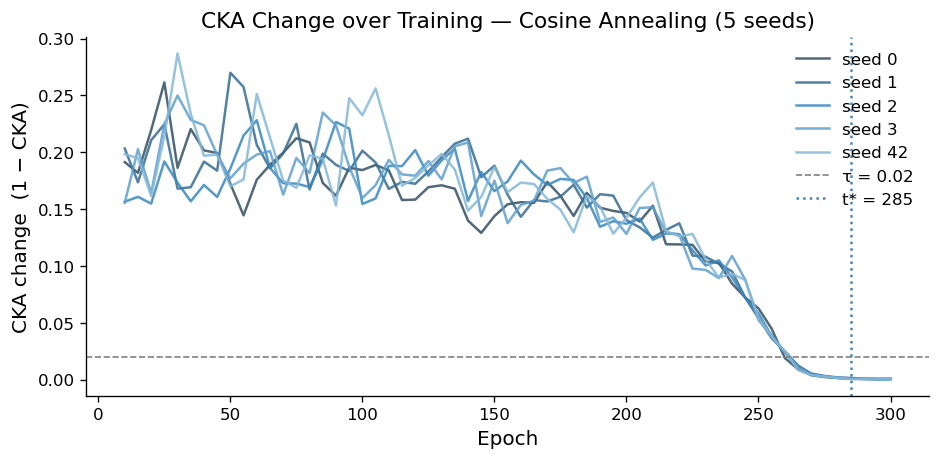

In [6]:
# ── Figure 1a: Cosine Annealing — CKA change curves (5 seeds) ─────────────────
# Caption: CKA change (1-CKA) vs training epoch for all five cosine-annealing seeds.
# The curve decays as representations stabilize. The vertical line marks t*=285
# (the epoch where CKA-based stabilization was first triggered across most seeds).

fig, ax = plt.subplots(figsize=(8, 4))

for idx, seed in enumerate(SEEDS):
    df     = cosine_cka_dfs[seed]
    epochs = df['epoch_curr'].values
    change = df['cka_change'].values
    label  = SEED_LABELS[idx]
    ax.plot(epochs, change, color=SEED_PALETTE[idx], linewidth=1.5, label=label, alpha=0.85)

ax.axhline(TAU, color='gray', linestyle='--', linewidth=1.0, label=f'τ = {TAU}')
ax.axvline(285, color='steelblue', linestyle=':', linewidth=1.5, label='t* = 285')

ax.set_xlabel('Epoch')
ax.set_ylabel('CKA change  (1 − CKA)')
ax.set_title('CKA Change over Training — Cosine Annealing (5 seeds)')
ax.legend(loc='upper right', frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(COSINE_ROOT, 'fig1a_cka_cosine.png'), dpi=150, bbox_inches='tight')
plt.show()

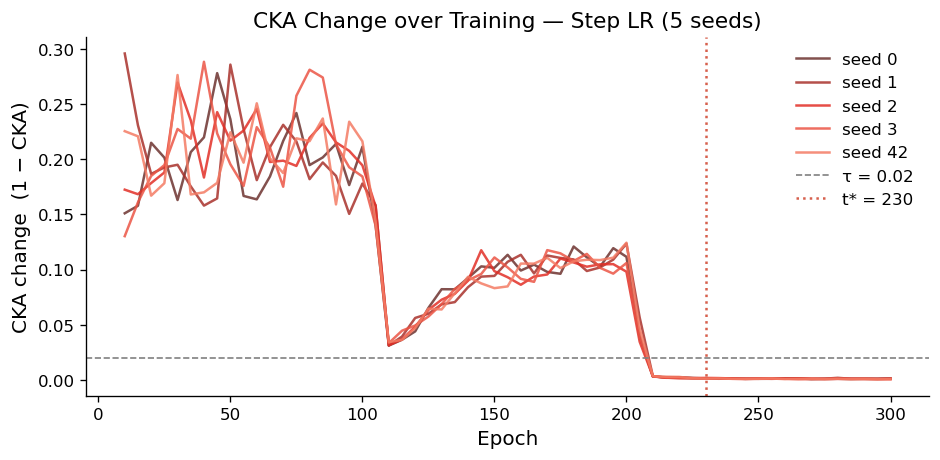

In [7]:
# ── Figure 1b: Step LR — CKA change curves (5 seeds) ─────────────────────────
# Caption: CKA change vs epoch under a step learning-rate schedule. Stabilization
# occurs earlier (t*=230) than under cosine annealing, consistent with the sharper
# LR drop inducing faster geometric convergence.

steplr_seed_palette = sns.color_palette('Reds_d', 5)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))

for idx, seed in enumerate(SEEDS):
    df     = steplr_cka_dfs[seed]
    epochs = df['epoch_curr'].values
    change = df['cka_change'].values
    label  = SEED_LABELS[idx]
    ax.plot(epochs, change, color=steplr_seed_palette[idx], linewidth=1.5, label=label, alpha=0.85)

ax.axhline(TAU, color='gray', linestyle='--', linewidth=1.0, label=f'τ = {TAU}')
ax.axvline(230, color=COLOR_STEPLR, linestyle=':', linewidth=1.5, label='t* = 230')

ax.set_xlabel('Epoch')
ax.set_ylabel('CKA change  (1 − CKA)')
ax.set_title('CKA Change over Training — Step LR (5 seeds)')
ax.legend(loc='upper right', frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(STEPLR_ROOT, 'fig1b_cka_steplr.png'), dpi=150, bbox_inches='tight')
plt.show()

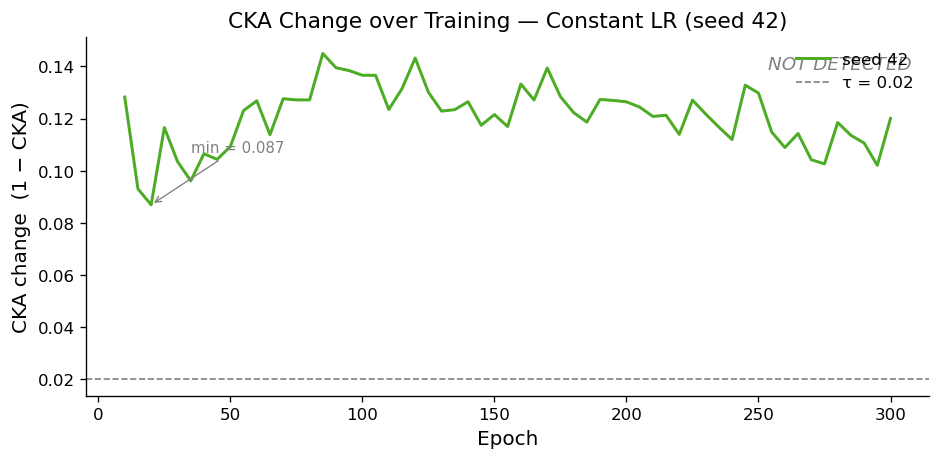

In [8]:
# ── Figure 1c: Constant LR — CKA change curve (seed 42) ──────────────────────
# Caption: CKA change vs epoch under a constant (non-decaying) learning rate.
# The curve oscillates around a high level and never crosses τ=0.02, so no
# stabilization epoch is detected. This is the "no schedule" baseline showing
# that LR annealing is necessary for geometric stabilization.

fig, ax = plt.subplots(figsize=(8, 4))

epochs = constlr_cka_df['epoch_curr'].values
change = constlr_cka_df['cka_change'].values

ax.plot(epochs, change, color=COLOR_CONSTLR, linewidth=1.8, label='seed 42')
ax.axhline(TAU, color='gray', linestyle='--', linewidth=1.0, label=f'τ = {TAU}')

# Mark the minimum CKA change to show how far it gets from crossing tau
min_change = change.min()
min_epoch  = epochs[change.argmin()]
ax.annotate(
    f'min = {min_change:.3f}',
    xy=(min_epoch, min_change),
    xytext=(min_epoch + 15, min_change + 0.02),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
    color='gray',
)

ax.text(
    0.98, 0.95, 'NOT DETECTED',
    transform=ax.transAxes, ha='right', va='top',
    fontsize=11, color='gray', style='italic',
)

ax.set_xlabel('Epoch')
ax.set_ylabel('CKA change  (1 − CKA)')
ax.set_title('CKA Change over Training — Constant LR (seed 42)')
ax.legend(loc='upper right', frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(CONSTLR_ROOT, 'fig1c_cka_constlr.png'), dpi=150, bbox_inches='tight')
plt.show()

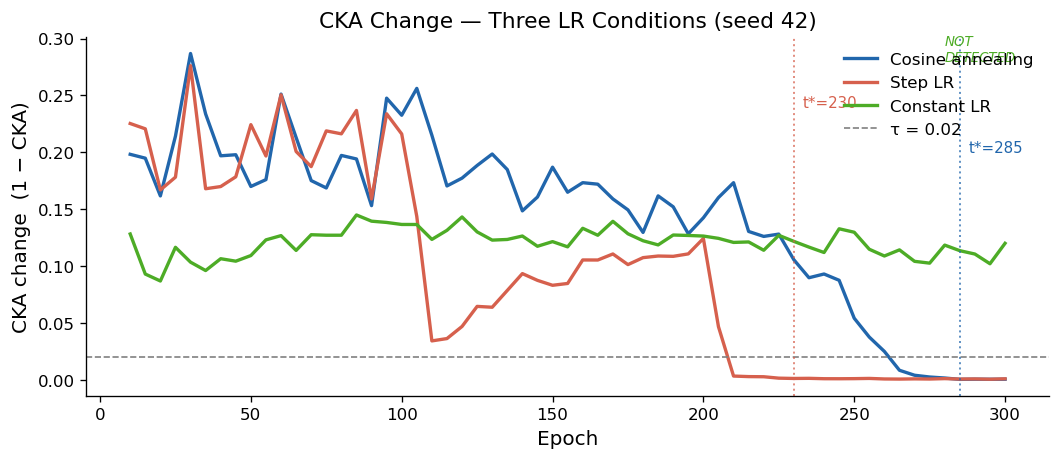

In [9]:
# ── Figure 1d: All three conditions overlaid (seed 42 only, for clarity) ──────
# Caption: Direct comparison of CKA change trajectories across the three LR
# conditions for seed 42. Vertical lines mark each condition's t*. Constant LR
# never stabilizes; step LR stabilizes earliest at epoch 230.

fig, ax = plt.subplots(figsize=(9, 4))

cosine_df = cosine_cka_dfs['seed_42']
steplr_df = steplr_cka_dfs['seed_42']

ax.plot(cosine_df['epoch_curr'], cosine_df['cka_change'],
        color=COLOR_COSINE,  linewidth=2.0, label='Cosine annealing')
ax.plot(steplr_df['epoch_curr'], steplr_df['cka_change'],
        color=COLOR_STEPLR,  linewidth=2.0, label='Step LR')
ax.plot(constlr_cka_df['epoch_curr'], constlr_cka_df['cka_change'],
        color=COLOR_CONSTLR, linewidth=2.0, label='Constant LR')

ax.axhline(TAU, color='gray', linestyle='--', linewidth=1.0, label=f'τ = {TAU}')
ax.axvline(285, color=COLOR_COSINE,  linestyle=':', linewidth=1.2, alpha=0.7)
ax.axvline(230, color=COLOR_STEPLR,  linestyle=':', linewidth=1.2, alpha=0.7)

ax.text(285 + 3, 0.20, 't*=285', color=COLOR_COSINE,  fontsize=9)
ax.text(230 + 3, 0.24, 't*=230', color=COLOR_STEPLR,  fontsize=9)
ax.text(280,     0.28, 'NOT\nDETECTED', color=COLOR_CONSTLR, fontsize=8, style='italic')

ax.set_xlabel('Epoch')
ax.set_ylabel('CKA change  (1 − CKA)')
ax.set_title('CKA Change — Three LR Conditions (seed 42)')
ax.legend(loc='upper right', frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(REPO_ROOT, 'results', 'fig1d_cka_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()

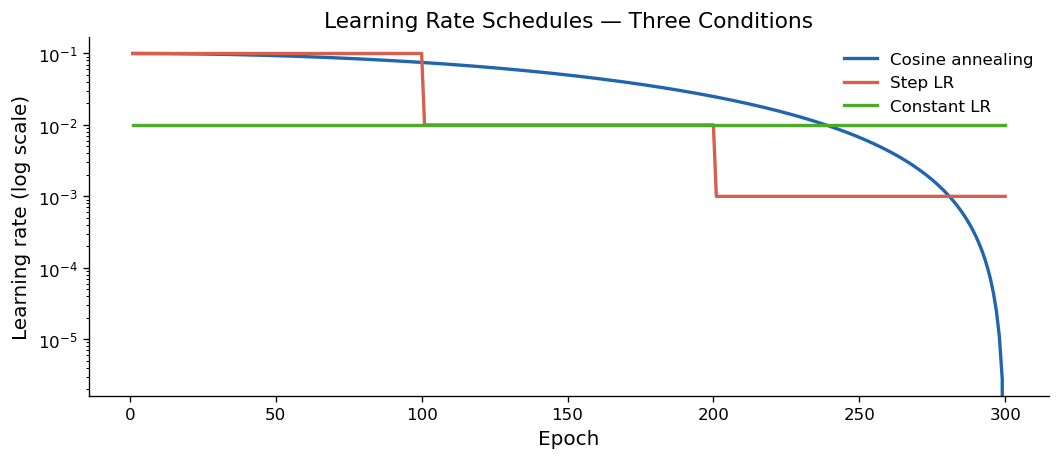

In [10]:
# ── Figure 1e: Learning rate schedules for all three conditions ───────────────
# Caption: Learning rate vs epoch for the three schedule conditions, derived
# analytically from config values. Cosine annealing decays smoothly from 0.1
# to 0; step LR drops discretely at epochs 100 and 200; constant LR holds at
# 0.01 throughout. The schedule shape determines when CKA-based stabilization
# fires (see Figure 1d and Figure 1f).

import math

# Parameters sourced directly from the three config files — no magic numbers
lr_cosine_init     = 0.1          # resnet18_cifar10.yaml: lr
lr_cosine_min      = 0.0          # CosineAnnealingLR default: eta_min = 0
lr_step_init       = 0.1          # resnet18_cifar10_steplr.yaml: lr
lr_step_milestones = [100, 200]   # resnet18_cifar10_steplr.yaml: lr_scheduler_milestones
lr_step_gamma      = 0.1          # resnet18_cifar10_steplr.yaml: lr_scheduler_gamma
lr_const_value     = 0.01         # resnet18_cifar10_constantlr.yaml: lr
n_epochs_total     = 300          # epochs (all three configs)

epochs_lr_plot = np.arange(1, n_epochs_total + 1)

# Cosine annealing: eta_min + 0.5*(eta_max - eta_min)*(1 + cos(pi*t/T_max))
lr_cosine_curve = lr_cosine_min + 0.5 * (lr_cosine_init - lr_cosine_min) * (
    1.0 + np.cos(np.pi * epochs_lr_plot / n_epochs_total)
)

# Step LR: multiply by gamma once each milestone epoch is passed
lr_step_curve = np.full(n_epochs_total, lr_step_init, dtype=float)
for milestone in lr_step_milestones:
    lr_step_curve[milestone:] *= lr_step_gamma

lr_constant_curve = np.full(n_epochs_total, lr_const_value, dtype=float)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(epochs_lr_plot, lr_cosine_curve,   color=COLOR_COSINE,  linewidth=2.0, label='Cosine annealing')
ax.plot(epochs_lr_plot, lr_step_curve,     color=COLOR_STEPLR,  linewidth=2.0, label='Step LR')
ax.plot(epochs_lr_plot, lr_constant_curve, color=COLOR_CONSTLR, linewidth=2.0, label='Constant LR')

ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate (log scale)')
ax.set_title('Learning Rate Schedules — Three Conditions')
ax.legend(frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(REPO_ROOT, 'results', 'fig1e_lr_schedules.png'),
            dpi=150, bbox_inches='tight')
plt.show()

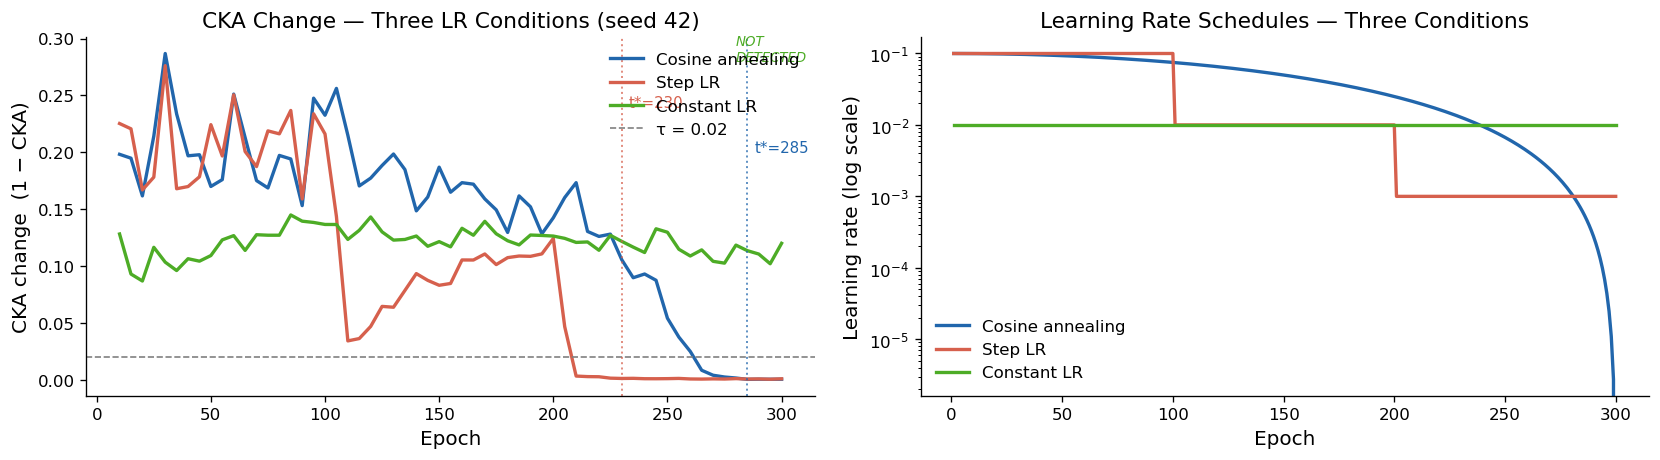

In [11]:
# ── Figure 1f: Side-by-side — CKA overlay (left) and LR schedules (right) ────
# Caption: Direct juxtaposition of CKA change trajectories (left) and the
# corresponding learning rate schedules (right) for seed 42. The timing of
# LR drops (step LR) and the final annealing phase (cosine) aligns with the
# onset of CKA stabilization, suggesting that LR decay drives geometric convergence.

cosine_df_s42 = cosine_cka_dfs['seed_42']
steplr_df_s42 = steplr_cka_dfs['seed_42']

fig, (ax_cka, ax_lr) = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: CKA change overlay (mirrors Figure 1d) ─────────────────────────────
ax_cka.plot(cosine_df_s42['epoch_curr'], cosine_df_s42['cka_change'],
            color=COLOR_COSINE,  linewidth=2.0, label='Cosine annealing')
ax_cka.plot(steplr_df_s42['epoch_curr'], steplr_df_s42['cka_change'],
            color=COLOR_STEPLR,  linewidth=2.0, label='Step LR')
ax_cka.plot(constlr_cka_df['epoch_curr'], constlr_cka_df['cka_change'],
            color=COLOR_CONSTLR, linewidth=2.0, label='Constant LR')
ax_cka.axhline(TAU, color='gray', linestyle='--', linewidth=1.0, label=f'τ = {TAU}')
ax_cka.axvline(285, color=COLOR_COSINE,  linestyle=':', linewidth=1.2, alpha=0.7)
ax_cka.axvline(230, color=COLOR_STEPLR,  linestyle=':', linewidth=1.2, alpha=0.7)
ax_cka.text(285 + 3, 0.20, 't*=285', color=COLOR_COSINE,  fontsize=9)
ax_cka.text(230 + 3, 0.24, 't*=230', color=COLOR_STEPLR,  fontsize=9)
ax_cka.text(280,     0.28, 'NOT\nDETECTED', color=COLOR_CONSTLR, fontsize=8, style='italic')
ax_cka.set_xlabel('Epoch')
ax_cka.set_ylabel('CKA change  (1 − CKA)')
ax_cka.set_title('CKA Change — Three LR Conditions (seed 42)')
ax_cka.legend(loc='upper right', frameon=False)

# ── Right: LR schedules (values recomputed from configs) ─────────────────────
ax_lr.plot(epochs_lr_plot, lr_cosine_curve,   color=COLOR_COSINE,  linewidth=2.0, label='Cosine annealing')
ax_lr.plot(epochs_lr_plot, lr_step_curve,     color=COLOR_STEPLR,  linewidth=2.0, label='Step LR')
ax_lr.plot(epochs_lr_plot, lr_constant_curve, color=COLOR_CONSTLR, linewidth=2.0, label='Constant LR')
ax_lr.set_yscale('log')
ax_lr.set_xlabel('Epoch')
ax_lr.set_ylabel('Learning rate (log scale)')
ax_lr.set_title('Learning Rate Schedules — Three Conditions')
ax_lr.legend(frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(REPO_ROOT, 'results', 'fig1f_cka_lr_side_by_side.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 2 · Stabilization Summary Table

t*_CKA per seed per condition. `NOT_DETECTED` means the CKA change never fell below τ=0.02
for K=5 consecutive pairs.

In [12]:
# Build stabilization summary table across all seeds and conditions
rows = []
for seed in SEEDS:
    cosine_t  = cosine_stab[seed]['CKA']
    steplr_t  = steplr_stab[seed]['CKA']
    # Constant LR only has seed_42
    if seed == 'seed_42':
        constlr_summary = load_stabilization_summary(CONSTLR_ROOT, seed) if os.path.exists(
            os.path.join(CONSTLR_ROOT, seed, 'stabilization_summary.csv')
        ) else {}
        constlr_t = constlr_summary.get('CKA', 'NOT_DETECTED')
    else:
        constlr_t = 'N/A'
    rows.append({
        'Seed'             : seed.replace('_', ' '),
        'Cosine t*_CKA'    : cosine_t,
        'Step LR t*_CKA'   : steplr_t,
        'Constant LR t*_CKA': constlr_t,
    })

stab_table = pd.DataFrame(rows)

def highlight_not_detected(val):
    if str(val) == 'NOT_DETECTED':
        return 'color: #d65f5f; font-weight: bold'
    if str(val) == 'N/A':
        return 'color: #aaaaaa'
    return 'color: #1a9641; font-weight: bold'

display(stab_table.style
    .applymap(highlight_not_detected, subset=['Cosine t*_CKA', 'Step LR t*_CKA', 'Constant LR t*_CKA'])
    .set_caption('Stabilization epoch t*_CKA per seed per condition (τ=0.02, K=5)')
    .set_properties(**{'text-align': 'center'})
)

,Seed,Cosine t*_CKA,Step LR t*_CKA,Constant LR t*_CKA
0,seed 0,280,230,N/A
1,seed 1,285,230,N/A
2,seed 2,285,230,N/A
3,seed 3,285,230,N/A
4,seed 42,285,230,NOT_DETECTED


---
## 3 · Surrogate Results — Cosine Annealing

Surrogates trained on frozen penultimate-layer features at epoch 285 (t*).  
`accuracy_gap = surrogate_test_acc − network_test_acc`. A positive gap means the surrogate
matches or exceeds the full network head.

In [13]:
# Load surrogate results for cosine annealing at epoch 285
cosine_surrogate_dfs = [
    load_surrogates(COSINE_ROOT, seed, epoch_tag=285)
    for seed in SEEDS
]
cosine_surrogates = pd.concat(cosine_surrogate_dfs, ignore_index=True)
cosine_surrogates['surrogate_label'] = cosine_surrogates['surrogate_type'].map(surrogate_display_name)
cosine_surrogates['seed_label']      = cosine_surrogates['seed'].str.replace('_', ' ')

print(f'Loaded {len(cosine_surrogates)} rows (5 seeds × 3 surrogates)')
cosine_surrogates[['seed', 'surrogate_label', 'surrogate_test_acc', 'network_test_acc', 'accuracy_gap']]

Loaded 15 rows (5 seeds × 3 surrogates)


,seed,surrogate_label,surrogate_test_acc,network_test_acc,accuracy_gap
0,seed_0,Linear probe,0.9554,0.9561,0.0007
1,seed_0,LightGBM,0.9487,0.9561,0.0074
2,seed_0,Random Forest,0.9547,0.9561,0.0014
3,seed_1,Linear probe,0.9552,0.9545,-0.0007
4,seed_1,LightGBM,0.9492,0.9545,0.0053
5,seed_1,Random Forest,0.9550,0.9545,-0.0005
6,seed_2,Linear probe,0.9543,0.9544,0.0001
7,seed_2,LightGBM,0.9491,0.9544,0.0053
8,seed_2,Random Forest,0.9537,0.9544,0.0007
9,seed_3,Linear probe,0.9548,0.9553,0.0005


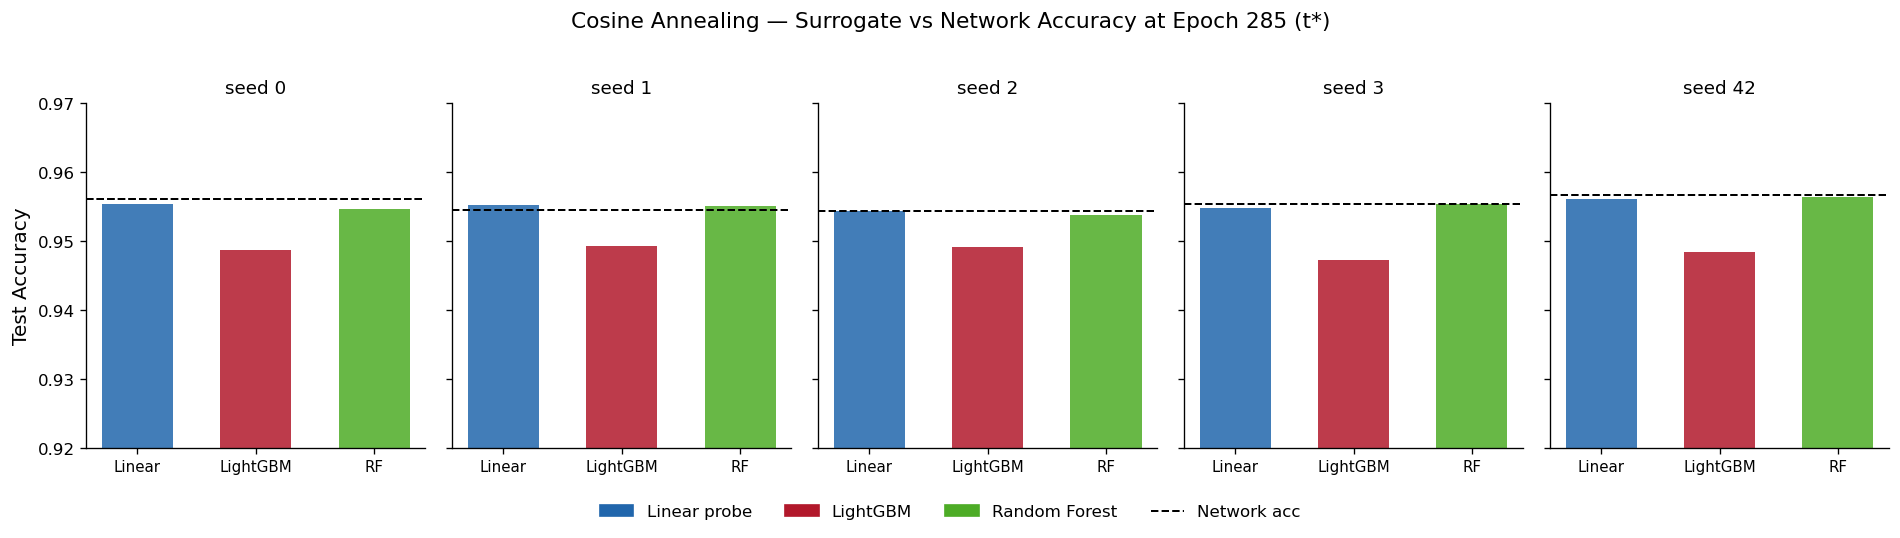

In [14]:
# ── Figure 3a: Cosine Annealing — Surrogate vs Network Accuracy (bar chart) ───
# Caption: For each seed, grouped bars show the full-network test accuracy vs each
# surrogate's test accuracy at the freeze epoch (285). All surrogates closely match
# network performance, confirming representational sufficiency at t*.

surrogate_order  = ['Linear probe', 'LightGBM', 'Random Forest']
surrogate_colors = ['#2166ac', '#b2182b', '#4dac26']

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

for ax_idx, (seed, ax) in enumerate(zip(SEEDS, axes)):
    seed_df = cosine_surrogates[cosine_surrogates['seed'] == seed].copy()
    seed_df = seed_df.set_index('surrogate_label').reindex(surrogate_order)

    network_acc    = seed_df['network_test_acc'].iloc[0]
    surrogate_accs = seed_df['surrogate_test_acc'].values
    labels         = surrogate_order

    x_positions = np.arange(len(labels))
    bars = ax.bar(x_positions, surrogate_accs, color=surrogate_colors,
                  width=0.6, alpha=0.85, zorder=2)
    ax.axhline(network_acc, color='black', linestyle='--', linewidth=1.2,
               label='Network acc', zorder=3)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Linear', 'LightGBM', 'RF'], fontsize=9)
    ax.set_title(SEED_LABELS[ax_idx], fontsize=11)
    ax.set_ylim(0.92, 0.97)
    ax.grid(False)
    if ax_idx == 0:
        ax.set_ylabel('Test Accuracy')
        ax.axhline(network_acc, color='black', linestyle='--', linewidth=1.2, label='Network')

fig.suptitle('Cosine Annealing — Surrogate vs Network Accuracy at Epoch 285 (t*)',
             fontsize=13, y=1.01)

legend_handles = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(surrogate_colors, surrogate_order)
] + [plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='Network acc')]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig(os.path.join(COSINE_ROOT, 'fig3a_cosine_surrogate_bars.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Accuracy gap table — cosine annealing
# Positive = surrogate beats network; negative = surrogate below network.

pivot_cosine = cosine_surrogates.pivot_table(
    index='seed_label',
    columns='surrogate_label',
    values='accuracy_gap',
)[surrogate_order]

# Add network test accuracy column for reference
network_accs = cosine_surrogates.groupby('seed_label')['network_test_acc'].first()
pivot_cosine.insert(0, 'Network acc', network_accs)

def fmt_gap(val):
    if pd.isna(val) or not isinstance(val, float):
        return ''
    return f'{val:+.4f}'

def color_gap(val):
    if pd.isna(val) or not isinstance(val, float):
        return ''
    if val >= 0:
        return 'color: #1a9641'
    return 'color: #d65f5f'

gap_cols = surrogate_order
display(
    pivot_cosine.style
    .format({'Network acc': '{:.4f}', **{c: fmt_gap for c in gap_cols}})
    .applymap(color_gap, subset=gap_cols)
    .set_caption('Cosine Annealing — accuracy_gap = surrogate_test_acc − network_test_acc at epoch 285')
)

surrogate_label,Network acc,Linear probe,LightGBM,Random Forest
seed_label,,,,
seed 0,0.9561,+0.0007,+0.0074,+0.0014
seed 1,0.9545,-0.0007,+0.0053,-0.0005
seed 2,0.9544,+0.0001,+0.0053,+0.0007
seed 3,0.9553,+0.0005,+0.0081,-0.0001
seed 42,0.9567,+0.0006,+0.0083,+0.0003


---
## 4 · Surrogate Results — Step LR

Surrogates trained on frozen features at epoch 230 (t* = 230 for all 5 seeds).

In [16]:
steplr_surrogate_dfs = [
    load_surrogates(STEPLR_ROOT, seed, epoch_tag=230)
    for seed in SEEDS
]
steplr_surrogates = pd.concat(steplr_surrogate_dfs, ignore_index=True)
steplr_surrogates['surrogate_label'] = steplr_surrogates['surrogate_type'].map(surrogate_display_name)
steplr_surrogates['seed_label']      = steplr_surrogates['seed'].str.replace('_', ' ')

print(f'Loaded {len(steplr_surrogates)} rows')
steplr_surrogates[['seed', 'surrogate_label', 'surrogate_test_acc', 'network_test_acc', 'accuracy_gap']]

Loaded 15 rows


,seed,surrogate_label,surrogate_test_acc,network_test_acc,accuracy_gap
0,seed_0,Linear probe,0.9525,0.9526,0.0001
1,seed_0,LightGBM,0.9463,0.9526,0.0063
2,seed_0,Random Forest,0.9530,0.9526,-0.0004
3,seed_1,Linear probe,0.9506,0.9511,0.0005
4,seed_1,LightGBM,0.9478,0.9511,0.0033
5,seed_1,Random Forest,0.9501,0.9511,0.0010
6,seed_2,Linear probe,0.9502,0.9494,-0.0008
7,seed_2,LightGBM,0.9460,0.9494,0.0034
8,seed_2,Random Forest,0.9499,0.9494,-0.0005
9,seed_3,Linear probe,0.9489,0.9493,0.0004


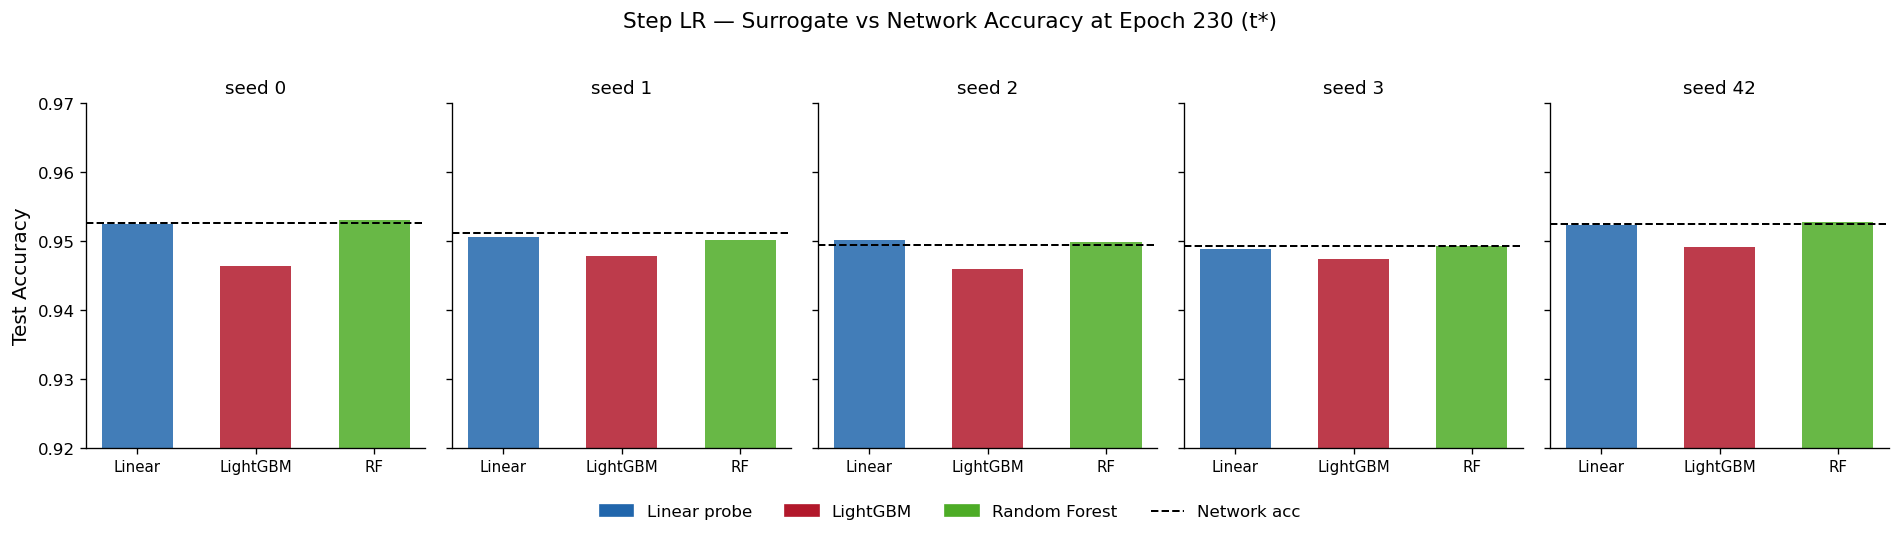

In [17]:
# ── Figure 4a: Step LR — Surrogate vs Network Accuracy (bar chart) ────────────
# Caption: Same as Figure 3a but under the step LR schedule, with surrogates frozen
# at epoch 230. Accuracy gaps remain small, supporting sufficiency at the earlier t*.

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

for ax_idx, (seed, ax) in enumerate(zip(SEEDS, axes)):
    seed_df = steplr_surrogates[steplr_surrogates['seed'] == seed].copy()
    seed_df = seed_df.set_index('surrogate_label').reindex(surrogate_order)

    network_acc    = seed_df['network_test_acc'].iloc[0]
    surrogate_accs = seed_df['surrogate_test_acc'].values

    x_positions = np.arange(len(surrogate_order))
    ax.bar(x_positions, surrogate_accs, color=surrogate_colors,
           width=0.6, alpha=0.85, zorder=2)
    ax.axhline(network_acc, color='black', linestyle='--', linewidth=1.2, zorder=3)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Linear', 'LightGBM', 'RF'], fontsize=9)
    ax.set_title(SEED_LABELS[ax_idx], fontsize=11)
    ax.set_ylim(0.92, 0.97)
    ax.grid(False)
    if ax_idx == 0:
        ax.set_ylabel('Test Accuracy')

fig.suptitle('Step LR — Surrogate vs Network Accuracy at Epoch 230 (t*)',
             fontsize=13, y=1.01)
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig(os.path.join(STEPLR_ROOT, 'fig4a_steplr_surrogate_bars.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Accuracy gap table — step LR

pivot_steplr = steplr_surrogates.pivot_table(
    index='seed_label',
    columns='surrogate_label',
    values='accuracy_gap',
)[surrogate_order]

network_accs_steplr = steplr_surrogates.groupby('seed_label')['network_test_acc'].first()
pivot_steplr.insert(0, 'Network acc', network_accs_steplr)

display(
    pivot_steplr.style
    .format({'Network acc': '{:.4f}', **{c: fmt_gap for c in surrogate_order}})
    .applymap(color_gap, subset=surrogate_order)
    .set_caption('Step LR — accuracy_gap = surrogate_test_acc − network_test_acc at epoch 230')
)

surrogate_label,Network acc,Linear probe,LightGBM,Random Forest
seed_label,,,,
seed 0,0.9526,+0.0001,+0.0063,-0.0004
seed 1,0.9511,+0.0005,+0.0033,+0.0010
seed 2,0.9494,-0.0008,+0.0034,-0.0005
seed 3,0.9493,+0.0004,+0.0019,+0.0001
seed 42,0.9524,+0.0001,+0.0033,-0.0003


---
## 5 · Surrogate Results — Constant LR

Only seed 42 was run under constant LR.  
Surrogates evaluated at both epoch 200 and epoch 285 (no stabilization epoch detected).

In [19]:
constlr_surrogates_200 = load_surrogates(CONSTLR_ROOT, 'seed_42', epoch_tag=200)
constlr_surrogates_285 = load_surrogates(CONSTLR_ROOT, 'seed_42', epoch_tag=285)

for df, tag in [(constlr_surrogates_200, 'epoch 200'), (constlr_surrogates_285, 'epoch 285')]:
    df['surrogate_label'] = df['surrogate_type'].map(surrogate_display_name)
    print(f'--- {tag} ---')
    print(df[['surrogate_label', 'surrogate_test_acc', 'network_test_acc', 'accuracy_gap']].to_string(index=False))
    print()

--- epoch 200 ---
surrogate_label  surrogate_test_acc  network_test_acc  accuracy_gap
   Linear probe              0.9252            0.9155       -0.0097
       LightGBM              0.9245            0.9155       -0.0090
  Random Forest              0.9244            0.9155       -0.0089

--- epoch 285 ---
surrogate_label  surrogate_test_acc  network_test_acc  accuracy_gap
   Linear probe              0.9272             0.922       -0.0052
       LightGBM              0.9251             0.922       -0.0031
  Random Forest              0.9264             0.922       -0.0044



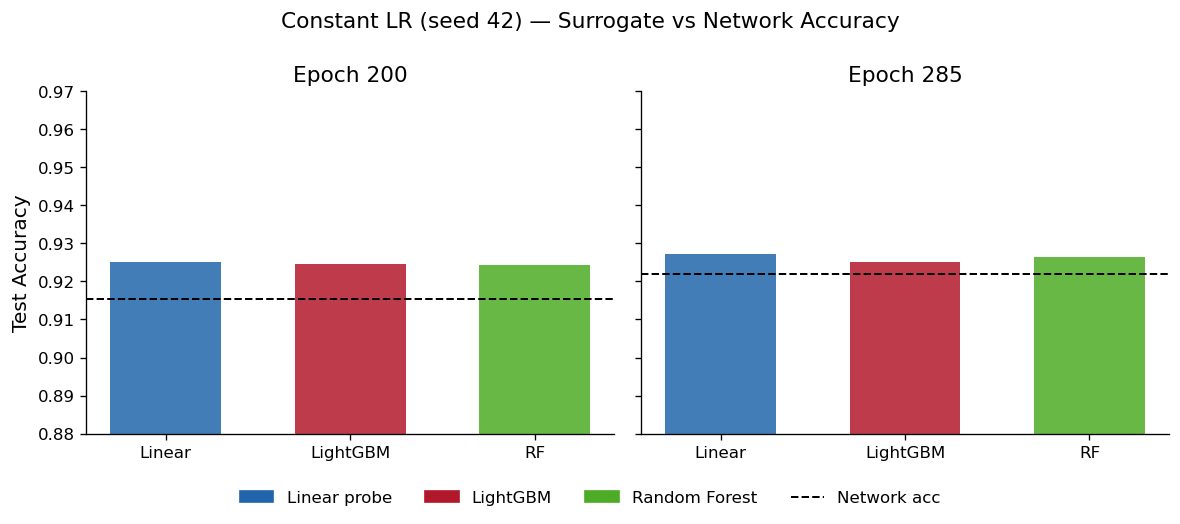

In [20]:
# ── Figure 5a: Constant LR — Surrogate vs Network at epochs 200 and 285 ───────
# Caption: Under constant LR, no geometric stabilization is detected. Nonetheless,
# surrogates are evaluated at epochs 200 and 285 to measure functional sufficiency.
# Lower surrogate accuracy at epoch 200 vs 285 shows representations are still improving.

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, (df, epoch_label) in zip(axes, [
    (constlr_surrogates_200, 'Epoch 200'),
    (constlr_surrogates_285, 'Epoch 285'),
]):
    df_indexed     = df.set_index('surrogate_label').reindex(surrogate_order)
    network_acc    = df_indexed['network_test_acc'].iloc[0]
    surrogate_accs = df_indexed['surrogate_test_acc'].values
    x_positions    = np.arange(len(surrogate_order))

    ax.bar(x_positions, surrogate_accs, color=surrogate_colors,
           width=0.6, alpha=0.85, zorder=2)
    ax.axhline(network_acc, color='black', linestyle='--', linewidth=1.2, zorder=3)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Linear', 'LightGBM', 'RF'])
    ax.set_title(epoch_label)
    ax.set_ylim(0.88, 0.97)
    ax.grid(False)

axes[0].set_ylabel('Test Accuracy')
fig.suptitle('Constant LR (seed 42) — Surrogate vs Network Accuracy', fontsize=13)
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig(os.path.join(CONSTLR_ROOT, 'fig5a_constlr_surrogate_bars.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Accuracy gap table — constant LR (both epochs)

constlr_combined = pd.concat([constlr_surrogates_200, constlr_surrogates_285], ignore_index=True)
constlr_combined['surrogate_label'] = constlr_combined['surrogate_type'].map(surrogate_display_name)

pivot_constlr = constlr_combined.pivot_table(
    index='epoch',
    columns='surrogate_label',
    values='accuracy_gap',
)[surrogate_order]

network_accs_constlr = constlr_combined.groupby('epoch')['network_test_acc'].first()
pivot_constlr.insert(0, 'Network acc', network_accs_constlr)

display(
    pivot_constlr.style
    .format({'Network acc': '{:.4f}', **{c: fmt_gap for c in surrogate_order}})
    .applymap(color_gap, subset=surrogate_order)
    .set_caption('Constant LR (seed 42) — accuracy_gap at epochs 200 and 285')
)

surrogate_label,Network acc,Linear probe,LightGBM,Random Forest
epoch,,,,
200,0.9155,-0.0097,-0.0090,-0.0089
285,0.9220,-0.0052,-0.0031,-0.0044


---
## 6 · Cross-condition Comparison

Single table and bar chart comparing all three conditions on mean network accuracy and
mean surrogate accuracy gaps across seeds.

In [22]:
def condition_summary(surrogates_df, condition_name, t_star):
    """Compute per-condition summary statistics for the cross-condition comparison table."""
    mean_network_acc = surrogates_df['network_test_acc'].mean()

    lr_gap  = surrogates_df[surrogates_df['surrogate_type'] == 'logistic_regression']['accuracy_gap'].mean()
    gbm_gap = surrogates_df[surrogates_df['surrogate_type'] == 'lightgbm']['accuracy_gap'].mean()
    rf_gap  = surrogates_df[surrogates_df['surrogate_type'] == 'random_forest']['accuracy_gap'].mean()

    return {
        'Condition'          : condition_name,
        't*_CKA'             : t_star,
        'Mean network acc'   : mean_network_acc,
        'Mean LR gap'        : lr_gap,
        'Mean LightGBM gap'  : gbm_gap,
        'Mean RF gap'        : rf_gap,
    }

# Cosine: 5 seeds at epoch 285; t*=285 (majority)
# Step LR: 5 seeds at epoch 230; t*=230 (all seeds)
# Constant LR: seed 42 at epoch 285 (no t* detected — use later epoch for fair comparison)

constlr_285_only = constlr_surrogates_285.copy()
constlr_285_only['surrogate_label'] = constlr_285_only['surrogate_type'].map(surrogate_display_name)

rows_cross = [
    condition_summary(cosine_surrogates,  'Cosine annealing', '285 (t*)'),
    condition_summary(steplr_surrogates,  'Step LR',          '230 (t*)'),
    condition_summary(constlr_285_only,   'Constant LR',      'NOT_DETECTED'),
]

cross_df = pd.DataFrame(rows_cross)
cross_df

,Condition,t*_CKA,Mean network acc,Mean LR gap,Mean LightGBM gap,Mean RF gap
0,Cosine annealing,285 (t*),0.95540,0.00024,0.00688,0.00036
1,Step LR,230 (t*),0.95096,0.00006,0.00364,-0.00002
2,Constant LR,NOT_DETECTED,0.92200,-0.00520,-0.00310,-0.00440


In [23]:
# Display styled cross-condition summary table
gap_cols_cross = ['Mean LR gap', 'Mean LightGBM gap', 'Mean RF gap']

display(
    cross_df.style
    .format({
        'Mean network acc': '{:.4f}',
        **{c: fmt_gap for c in gap_cols_cross},
    })
    .applymap(color_gap, subset=gap_cols_cross)
    .set_caption(
        'Cross-condition summary. Positive gap = surrogate beats network; '
        'negative = surrogate below network. Cosine/StepLR: mean over 5 seeds. '
        'Constant LR: single seed (42), epoch 285.'
    )
    .hide(axis='index')
)

Condition,t*_CKA,Mean network acc,Mean LR gap,Mean LightGBM gap,Mean RF gap
Cosine annealing,285 (t*),0.9554,+0.0002,+0.0069,+0.0004
Step LR,230 (t*),0.9510,+0.0001,+0.0036,-0.0000
Constant LR,NOT_DETECTED,0.9220,-0.0052,-0.0031,-0.0044


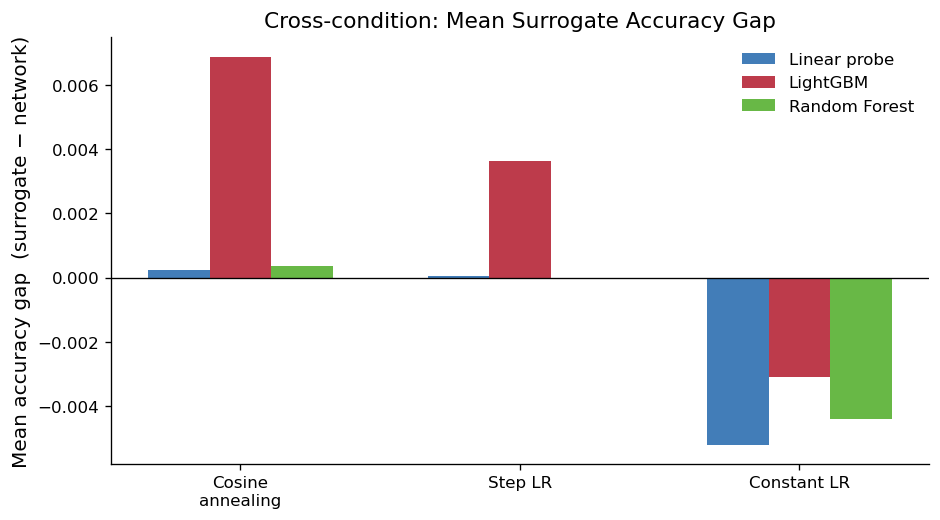

In [24]:
# ── Figure 6: Cross-condition — Mean Surrogate Accuracy Gap ───────────────────
# Caption: Mean accuracy gap (surrogate − network) across the three LR conditions.
# Values close to zero confirm surrogates match the frozen network head. Positive
# values indicate the surrogate slightly outperforms the full-network head, possibly
# because the surrogate has more capacity (LightGBM, RF) or less overfitting.

condition_labels = ['Cosine\nannealing', 'Step LR', 'Constant LR']
condition_colors = [COLOR_COSINE, COLOR_STEPLR, COLOR_CONSTLR]

lr_gaps  = [r['Mean LR gap']       for r in rows_cross]
gbm_gaps = [r['Mean LightGBM gap'] for r in rows_cross]
rf_gaps  = [r['Mean RF gap']       for r in rows_cross]

x_cond   = np.arange(3)
bar_w    = 0.22

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(x_cond - bar_w, lr_gaps,  width=bar_w, label='Linear probe',  color='#2166ac', alpha=0.85)
ax.bar(x_cond,         gbm_gaps, width=bar_w, label='LightGBM',      color='#b2182b', alpha=0.85)
ax.bar(x_cond + bar_w, rf_gaps,  width=bar_w, label='Random Forest', color='#4dac26', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_cond)
ax.set_xticklabels(condition_labels)
ax.set_ylabel('Mean accuracy gap  (surrogate − network)')
ax.set_title('Cross-condition: Mean Surrogate Accuracy Gap')
ax.legend(frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(COSINE_ROOT, 'fig6_cross_condition_gap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 7 · CKA Epoch×Epoch Heatmap — Cosine Annealing, Seed 42

The Sharon & Dar (2024) style visualization requires all pairwise epoch CKA values
(full N×N matrix).  Only consecutive-pair CKA was computed in these experiments.

The heatmap below shows a **tridiagonal approximation**: the main diagonal is set to
1.0 (a representation is identical to itself), the immediate off-diagonals carry the
consecutive-pair CKA values from `cka_results.csv`, and the remainder is left blank.
This reveals *when* CKA approaches 1.0 (i.e., when successive checkpoints stop changing),
even though the full block structure cannot be inferred without pairwise data.

To compute the full pairwise matrix on the cluster, run:
```
python metrics/cka.py --mode pairwise --config configs/resnet18_cifar10.yaml
```

In [25]:
# Load consecutive-pair CKA for cosine seed 42 and build sparse tridiagonal matrix
seed42_cka = cosine_cka_dfs['seed_42'].copy()

# Build sorted list of all epochs appearing in the data
epoch_prev_vals = seed42_cka['epoch_prev'].tolist()
epoch_curr_vals = seed42_cka['epoch_curr'].tolist()
all_epochs_set  = sorted(set(epoch_prev_vals + epoch_curr_vals))
epoch_list      = all_epochs_set
n_epochs        = len(epoch_list)

# Map epoch value → index in epoch_list
epoch_to_idx = {ep: i for i, ep in enumerate(epoch_list)}

# Initialize matrix with NaN; diagonal = 1.0
cka_matrix = np.full((n_epochs, n_epochs), np.nan)
np.fill_diagonal(cka_matrix, 1.0)

# Fill consecutive off-diagonals with measured CKA values
for _, row in seed42_cka.iterrows():
    i = epoch_to_idx[row['epoch_prev']]
    j = epoch_to_idx[row['epoch_curr']]
    cka_matrix[i, j] = row['cka_value']
    cka_matrix[j, i] = row['cka_value']   # symmetric

print(f'Matrix shape: {cka_matrix.shape}  |  epochs {epoch_list[0]}–{epoch_list[-1]}')
n_off_diag = int(np.sum(~np.isnan(cka_matrix)) - n_epochs)  # non-diagonal non-NaN entries
print(f'Filled {n_off_diag // 2} off-diagonal pairs (consecutive CKA values)')

Matrix shape: (60, 60)  |  epochs 5–300
Filled 59 off-diagonal pairs (consecutive CKA values)


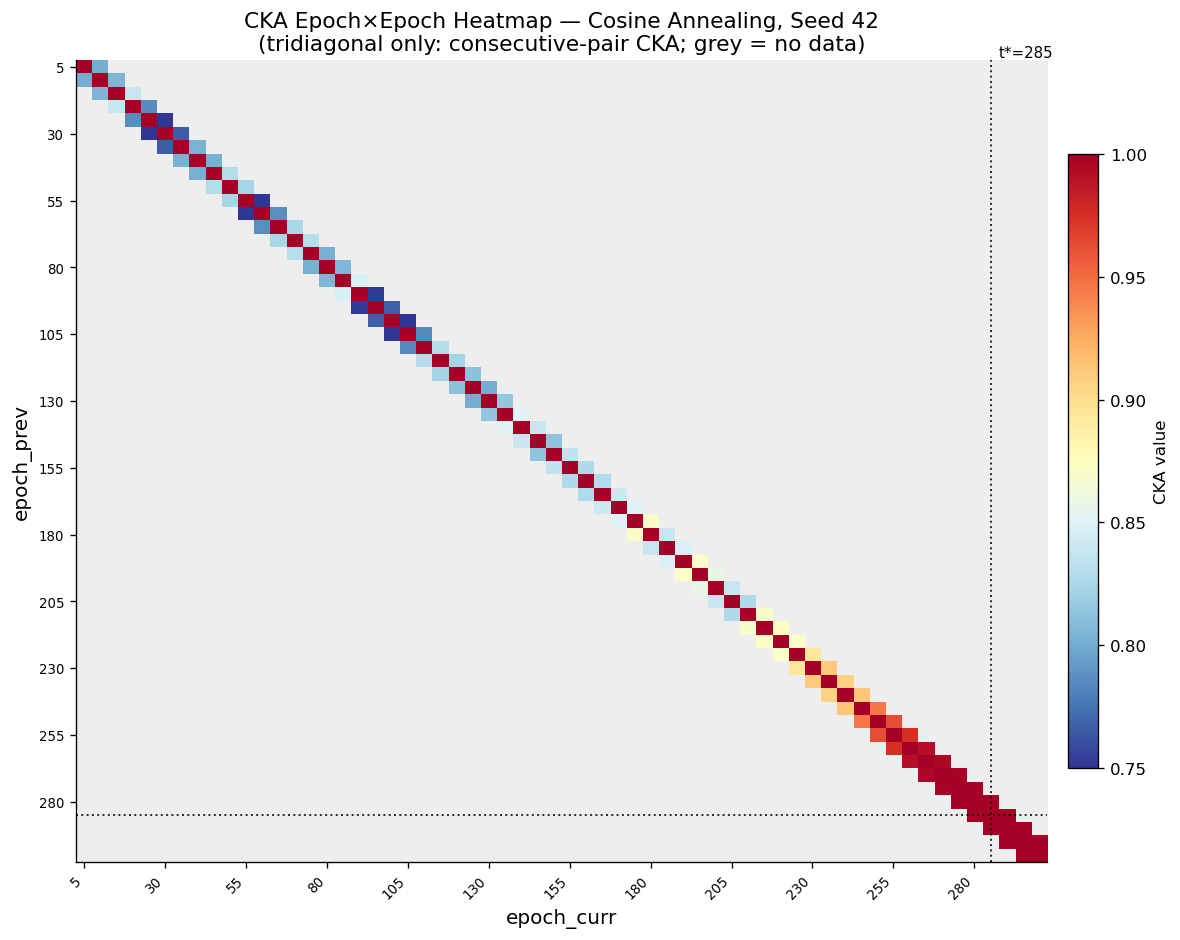

In [26]:
# ── Figure 7: CKA Epoch×Epoch Heatmap (tridiagonal) — Cosine Seed 42 ─────────
# Caption: Each cell (i, j) is colored by CKA(epoch_i, epoch_j). Only the main
# diagonal (CKA=1.0) and the immediate off-diagonals (consecutive-pair CKA from
# cka_results.csv) are filled; the rest is grey (no data). The transition to
# deep red near epoch 260–285 marks where CKA approaches 1.0 — the stabilization
# region. Full pairwise computation required for Sharon & Dar style block structure.

# Determine t* epoch from the stabilization summary
t_star_cosine_s42  = t_star_int_or_none(cosine_stab['seed_42']['CKA'])
t_star_idx         = epoch_to_idx.get(t_star_cosine_s42, None)

# Tick positions: show every 5th epoch label to avoid crowding
tick_step    = 5
tick_indices = list(range(0, n_epochs, tick_step))
tick_labels  = [str(epoch_list[i]) for i in tick_indices]

fig, ax = plt.subplots(figsize=(10, 8))

# Custom colormap: grey for NaN background, then Blues for low CKA → Reds for high
cmap = plt.get_cmap('RdYlBu_r').copy()
cmap.set_bad(color='#eeeeee')   # NaN cells shown as light grey

im = ax.imshow(
    cka_matrix,
    cmap=cmap,
    vmin=0.75,
    vmax=1.0,
    aspect='auto',
    interpolation='nearest',
)

# Mark t* as a cross-hair
if t_star_idx is not None:
    ax.axvline(t_star_idx, color='black', linewidth=1.2, linestyle=':', alpha=0.8)
    ax.axhline(t_star_idx, color='black', linewidth=1.2, linestyle=':', alpha=0.8)
    ax.text(
        t_star_idx + 0.5, 1.0,
        f't*={t_star_cosine_s42}',
        color='black', fontsize=9,
        transform=ax.get_xaxis_transform(),
        va='bottom',
    )

ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(tick_indices)
ax.set_yticklabels(tick_labels, fontsize=8)
ax.set_xlabel('epoch_curr')
ax.set_ylabel('epoch_prev')
ax.set_title(
    'CKA Epoch×Epoch Heatmap — Cosine Annealing, Seed 42\n'
    '(tridiagonal only: consecutive-pair CKA; grey = no data)'
)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('CKA value', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(COSINE_ROOT, 'fig7_cka_heatmap_seed42.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## Export

Run the cell below to export this notebook to `results/results_inspection.html`.

In [27]:
import subprocess
import sys

notebook_path = os.path.join(REPO_ROOT, 'notebooks', 'results_inspection.ipynb')
output_path   = os.path.join(REPO_ROOT, 'results', 'results_inspection.html')

result = subprocess.run(
    [
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'html',
        '--output', output_path,
        notebook_path,
    ],
    capture_output=True,
    text=True,
)

if result.returncode == 0:
    print(f'Exported to: {output_path}')
else:
    print('Export failed:')
    print(result.stderr)

Exported to: C:\Users\gabri\thesis\results\results_inspection.html
